<h2>Formating of DB-Data<h2>

In [1]:
from hilfsfunktionen.formating import get_unchanged_table, get_formated_table, get_table_with_keys, create_n_sentences
df_collection = {}
df_collection["unchanged_table"] = get_unchanged_table()
df_collection["formated_table"] = get_formated_table()
df_collection["formated_table_no_churn"] = df_collection["formated_table"].drop('churn', axis=1)
df_collection["formated_table_with_keys"] = get_table_with_keys(df_collection["formated_table"])
df_collection["formated_table_with_keys_no_churn"] = get_table_with_keys(df_collection["formated_table_no_churn"])
df_collection["n_sentences"] = {}
for n in [1, 5, 20, 50, 100]:
    df_collection["n_sentences"][f"{n}"] = create_n_sentences(df_collection["formated_table_with_keys_no_churn"], n)

#df_collection["formated_table_with_keys_no_churn"].head

<h2>Model Creation<h2>

In [2]:
from hilfsfunktionen.model_training import (
    ModelConfig, 
    ModelTrainer, 
    ModelRepository, 
    ExperimentRunner
)
from pathlib import Path

models = {}  

base_config = ModelConfig(
    vector_size = 50,      # Dimension der Wortvektoren; guter Kompromiss zwischen Ausdrucksstärke und Rechenaufwand
    window = 4,             # Kleines Kontextfenster; betont lokale, eher syntaktische Beziehungen
    epochs = 30,            # Viele Trainingsdurchläufe; bessere Anpassung, aber erhöhtes Overfitting-Risiko
    min_count = 1,          # Alle Wörter werden berücksichtigt; seltene Wörter sind jedoch oft verrauscht
    negative = 5,           # Anzahl negativer Beispiele; Standardwert mit gutem Qualitäts-/Zeit-Verhältnis
    sample = 0,             # Subsampling häufiger Wörter; verbessert Semantik, kann bei kleinen Korpora schaden
    hs = 0,                 # Hierarchical Softmax deaktiviert; Training erfolgt ausschließlich via Negative Sampling
    alpha = 0.025,          # Start-Lernrate; stabiler Trainingsbeginn, bei vielen Epochen kritisch
    seed = 1,               # Faester Zufallsstart; sorgt für Reproduzierbarkeit   
)

GRID = {
    "vector_size": [150],
    "window": [4],
    "sg": [0, 1],
    "epochs": [30],
    "negative": [5],
    "sample": [1e-3],
    "hs": [0],
    "alpha": [0.025],
    "seed": [1]
}

trainer = ModelTrainer()
repository = ModelRepository(base_dir=Path.cwd())
runner = ExperimentRunner(trainer, repository, base_config)


models = runner.run_grid_search(
    sentences=df_collection["n_sentences"]["20"],
    param_grid=GRID,
    #n_sentences_tokenized=df_collection["n_sentences"],
    num_sentences=10000, # Begrenzung der Trainingssätze; beschleunigt Training, limitiert Informationsgehalt
    verbose=False
)
    

<h2>Durchschnittliche Satzvektoren berechnen<h2>

In [3]:
from hilfsfunktionen.sentence_vectors import create_average_sentence_vectors

average_sentence_vectors = []

        
for model in models:
    vectors = create_average_sentence_vectors(
        model, 
        df_collection["formated_table_with_keys"], 
        base_dir=Path.cwd(), 
        verbose=False
    )
    average_sentence_vectors.append([vectors, model[1]])
#print(average_sentence_vectors[1])

<h2>Vektoren-Test Textbasiert<h2>

In [4]:
from hilfsfunktionen.benchmark_of_semantic_operatiors import run_full_vector_test

results = run_full_vector_test(model_list = models, verbose=False, df_with_keys=df_collection["formated_table_with_keys"], average_sentence_vectors = average_sentence_vectors, base_dir= Path.cwd())
#print(results)



In [5]:
if False:
    print(sorted(results.keys()))
    rankings = results["phase2_rankings_model0"]
    first_ref = list(rankings.keys())[0]
    print(sorted(rankings[first_ref]["top"].keys()))
    first_ref = list(rankings.keys())[0]
    print("TOP metrics:", sorted(rankings[first_ref]["top"].keys()))
    print("BOTTOM metrics:", sorted(rankings[first_ref]["bottom"].keys()))
    
    phase1 = results["phase1_model0"]
    print(phase1.columns.tolist())
    print(results["phase3_stats_model0"].keys())
    
    phase4 = results["phase4_separation_model0"]["summary_df"]
    phase4.to_csv("figures/phase4_separation_summary_model0.csv", index=False)
    
    phase3 = results["phase3_stats_model0"]
    pd.DataFrame(phase3["stats_df"]).T.to_csv("figures/phase3_summary_stats_model0.csv")


<h2>Visualisierung<h2>

In [6]:
from pathlib import Path
import matplotlib.pyplot as plt

FIGURE_DIR = Path("figures")
FIGURE_DIR.mkdir(exist_ok=True)

def render_figure(fig, name, dpi=300, show=True):
    """
    Centralized figure handling:
    - saves in publication-quality formats
    - optionally displays in Jupyter
    - closes figure to avoid memory leaks
    """
    fig.savefig(FIGURE_DIR / f"{name}.pdf")
    fig.savefig(FIGURE_DIR / f"{name}.png", dpi=dpi)

    if show:
        plt.show()

    plt.close(fig)

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from typing import List, Dict, Optional, Tuple
import matplotlib.cm as cm

# -----------------------------
# Globale Konfiguration
# -----------------------------
FIGURE_DIR = Path("figures")
FIGURE_DIR.mkdir(exist_ok=True)

# Farbpalette für konsistentes Design
COLORS = {
    'primary': '#2E86AB',      # Blauton
    'secondary': '#A23B72',    # Pink/Rosa
    'tertiary': '#F18F01',     # Orange
    'accent': '#C73E1D',       # Rot
    'neutral': '#6C757D',      # Grau
}

# Colormaps
CMAP_SEQUENTIAL = 'viridis'
CMAP_DIVERGING = 'RdBu_r'
CMAP_CATEGORICAL = 'Set2'

def render_figure(fig, name: str, dpi: int = 300, show: bool = True, 
                  formats: List[str] = ['pdf', 'png']):
    """
    Zentrale Figuren-Handhabung für konsistentes Speichern.
    """
    for fmt in formats:
        fig.savefig(FIGURE_DIR / f"{name}.{fmt}", dpi=dpi, bbox_inches='tight')
    
    if show:
        plt.show()
    
    plt.close(fig)

def set_publication_style():
    """Setzt einen konsistenten Publikationsstil für alle Plots."""
    plt.rcParams.update({
        'font.size': 10,
        'axes.titlesize': 12,
        'axes.labelsize': 11,
        'xtick.labelsize': 9,
        'ytick.labelsize': 9,
        'legend.fontsize': 9,
        'figure.titlesize': 13,
        'font.family': 'sans-serif',
        'font.sans-serif': ['Arial', 'DejaVu Sans'],
        'axes.grid': False,
        'axes.edgecolor': '#444444',
        'axes.linewidth': 0.8,
        'savefig.dpi': 300,
        'savefig.bbox': 'tight',
    })

# Stil beim Import setzen
set_publication_style()

# -----------------------------
# Helpers: Results-Zugriff (unverändert)
# -----------------------------
def _get_first_key(results: dict, prefix: str, model_idx: int | None = None) -> str:
    if model_idx is not None:
        key = f"{prefix}_model{model_idx}"
        if key not in results:
            raise KeyError(f"Key '{key}' nicht in results gefunden.")
        return key

    candidates = [k for k in results.keys() if k.startswith(prefix)]
    if not candidates:
        raise KeyError(f"Kein Key mit Prefix '{prefix}' in results gefunden.")
    return sorted(candidates)[0]

def _infer_metrics_from_rankings(rankings: dict) -> list[str]:
    any_ref = next(iter(rankings.keys()))
    top_dict = rankings[any_ref].get("top", {})
    if not isinstance(top_dict, dict):
        raise ValueError("rankings[ref]['top'] ist nicht dict.")
    metrics = sorted(list(top_dict.keys()))
    if not metrics:
        raise ValueError("Keine Metriken in rankings[ref]['top'] gefunden.")
    return metrics


def _jaccard(a: list, b: list) -> float:
    A, B = set(a), set(b)
    if len(A) == 0 and len(B) == 0:
        return 1.0
    if len(A) == 0 or len(B) == 0:
        return 0.0
    return len(A & B) / len(A | B)

def compute_jaccard_matrix_from_results(
    results: dict,
    which: str = "top",
    model_idx: int | None = None,
    rankings_prefix: str = "phase2_rankings",
    k: int = 200,
    metrics: list[str] | None = None,
) -> pd.DataFrame:
    rankings_key = _get_first_key(results, rankings_prefix, model_idx=model_idx)
    rankings = results[rankings_key]
    
    
    # Robust structure check:
    # Expected: dict[ref_id] -> {"top": {metric: [...]}, "bottom": {...}}
    if not isinstance(rankings, dict) or len(rankings) == 0:
        raise ValueError(f"{rankings_key} ist leer oder nicht dict.")

    # If someone passed the inner dict by mistake, it will have 'top'/'bottom' at top-level.
    if "top" in rankings or "bottom" in rankings:
        raise ValueError(
            f"{rankings_key} hat 'top'/'bottom' auf Top-Level. "
            "Erwartet wird dict[ref_id] -> {'top':..., 'bottom':...}."
        )

    if metrics is None:
        metrics = _infer_metrics_from_rankings(rankings)

    M = len(metrics)
    mat = np.zeros((M, M), dtype=float)

    ref_ids = list(rankings.keys())
    for i, mi in enumerate(metrics):
        for j, mj in enumerate(metrics):
            if i == j:
                mat[i, j] = 1.0
                continue

            vals = []
            for ref in ref_ids:
                ri = rankings[ref].get(which, {}).get(mi, [])[:k]
                rj = rankings[ref].get(which, {}).get(mj, [])[:k]
                vals.append(_jaccard(ri, rj))
            mat[i, j] = float(np.mean(vals)) if vals else np.nan
    print("INFO")
    print(list(rankings.keys())[:2])
    print(rankings[np.int64(2872)].keys())
    return pd.DataFrame(mat, index=metrics, columns=metrics)


# -----------------------------
# 1. HEATMAPS - Ranking Konsistenz
# -----------------------------
def plot_combined_top_bottom_heatmaps(
    results: dict,
    model_idx: int | None = None,
    k: int = 200,
    metrics: list[str] | None = None,
    rankings_prefix: str = "phase2_rankings",
    cmap: str = CMAP_SEQUENTIAL,
    figsize: tuple[int, int] = (13, 5),
    show: bool = True,
    save_name: str = "ranking_consistency_combined",
):
    """
    Plottet Top- und Bottom-Heatmaps nebeneinander mit gemeinsamer Colorbar.
    """
    # Daten berechnen
    top_df = compute_jaccard_matrix_from_results(
        results, which="top", model_idx=model_idx, 
        rankings_prefix=rankings_prefix, k=k, metrics=metrics
    )
    bottom_df = compute_jaccard_matrix_from_results(
        results, which="bottom", model_idx=model_idx, 
        rankings_prefix=rankings_prefix, k=k, metrics=metrics
    )
    
    # Gemeinsame Werteskala bestimmen (Diagonale ausschließen)
    top_values = top_df.values[~np.eye(len(top_df), dtype=bool)]
    bottom_values = bottom_df.values[~np.eye(len(bottom_df), dtype=bool)]
    all_values = np.concatenate([top_values, bottom_values])
    all_values = all_values[~np.isnan(all_values)]
    
    vmin = max(0.0, all_values.min() - 0.05)
    vmax = min(1.0, all_values.max() + 0.05)
    
    # Figure mit Subplots erstellen
    fig, axes = plt.subplots(1, 2, figsize=figsize, 
                             constrained_layout=True)
    
    # Top-200 Heatmap
    im1 = axes[0].imshow(
        top_df.values, 
        vmin=vmin, 
        vmax=vmax, 
        aspect='auto', 
        cmap=cmap,
        interpolation='nearest'
    )
    axes[0].set_xticks(range(len(top_df.columns)))
    axes[0].set_xticklabels(top_df.columns, rotation=45, ha='right')
    axes[0].set_yticks(range(len(top_df.index)))
    axes[0].set_yticklabels(top_df.index)
    axes[0].set_xlabel("Metrik", fontweight='medium')
    axes[0].set_ylabel("Metrik", fontweight='medium')
    axes[0].set_title(f"Top-{k} Konsistenz", fontweight='bold')
    axes[0].grid(False)
    
    # Bottom-200 Heatmap
    im2 = axes[1].imshow(
        bottom_df.values, 
        vmin=vmin, 
        vmax=vmax, 
        aspect='auto', 
        cmap=cmap,
        interpolation='nearest'
    )
    axes[1].set_xticks(range(len(bottom_df.columns)))
    axes[1].set_xticklabels(bottom_df.columns, rotation=45, ha='right')
    axes[1].set_yticks(range(len(bottom_df.index)))
    axes[1].set_yticklabels(bottom_df.index)
    axes[1].set_xlabel("Metrik", fontweight='medium')
    axes[1].set_ylabel("Metrik", fontweight='medium')
    axes[1].set_title(f"Bottom-{k} Konsistenz", fontweight='bold')
    axes[1].grid(False)
    
    # Gemeinsame Colorbar
    cbar = fig.colorbar(im1, ax=axes, shrink=0.8, pad=0.02)
    cbar.set_label("Jaccard-Index", fontweight='medium')
    
    render_figure(fig, save_name, show=show)

def plot_single_jaccard_heatmap(
    jaccard_df: pd.DataFrame,
    title: str,
    cmap: str = CMAP_SEQUENTIAL,
    figsize: tuple[int, int] = (8, 6),
    show: bool = True,
    save_name: str | None = None,
    annotate: bool = True,
):
    """
    Plottet eine einzelne Jaccard-Heatmap im Publikationsstil.
    """
    fig, ax = plt.subplots(figsize=figsize)
    
    # Werte ohne Diagonale für Skalierung
    values = jaccard_df.values[~np.eye(len(jaccard_df), dtype=bool)]
    values = values[~np.isnan(values)]
    
    vmin = max(0.0, values.min() - 0.05) if len(values) > 0 else 0.0
    vmax = min(1.0, values.max() + 0.05) if len(values) > 0 else 1.0
    
    # Heatmap mit seaborn für bessere Kontrolle
    if annotate:
        sns.heatmap(
            jaccard_df,
            annot=True,
            fmt=".2f",
            vmin=vmin,
            vmax=vmax,
            square=True,
            cbar=True,
            cmap=cmap,
            ax=ax,
            cbar_kws={
                'label': 'Jaccard-Index',
                'shrink': 0.8
            },
            linewidths=0.5,
            linecolor='white'
        )
    else:
        im = ax.imshow(
            jaccard_df.values,
            vmin=vmin,
            vmax=vmax,
            aspect='auto',
            cmap=cmap,
            interpolation='nearest'
        )
        plt.colorbar(im, ax=ax, label='Jaccard-Index', shrink=0.8)
        
        # Achsenbeschriftungen
        ax.set_xticks(range(len(jaccard_df.columns)))
        ax.set_xticklabels(jaccard_df.columns, rotation=45, ha='right')
        ax.set_yticks(range(len(jaccard_df.index)))
        ax.set_yticklabels(jaccard_df.index)
    
    ax.set_xlabel("Metrik", fontweight='medium')
    ax.set_ylabel("Metrik", fontweight='medium')
    ax.set_title(title, fontweight='bold')
    ax.grid(False)
    
    plt.tight_layout()
    
    if save_name:
        render_figure(fig, save_name, show=show)
    elif show:
        plt.show()
        plt.close(fig)

# -----------------------------
# 2. HISTOGRAMME - Phase 3 Verteilungen
# -----------------------------
def plot_phase3_histograms_combined(
    results: dict,
    model_idx: int | None = None,
    phase3_prefix: str = "phase3_stats",
    metrics: list[str] | None = None,
    max_cols: int = 3,
    figsize_per_subplot: tuple[int, int] = (4, 3),
    color: str = COLORS['primary'],
    show: bool = True,
    save_name: str = "phase3_histograms_combined",
):
    """
    Plottet alle Histogramme in einer gemeinsamen Figure.
    """
    phase3_key = _get_first_key(results, phase3_prefix, model_idx=model_idx)
    phase3 = results[phase3_key]
    hist = phase3.get("histograms")
    
    if hist is None:
        raise KeyError(f"{phase3_key} enthält kein 'histograms'.")
    
    if metrics is None:
        metrics = sorted(list(hist.keys()))
    
    n_metrics = len(metrics)
    n_cols = min(max_cols, n_metrics)
    n_rows = (n_metrics + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(
        n_rows, n_cols, 
        figsize=(n_cols * figsize_per_subplot[0], n_rows * figsize_per_subplot[1]),
        constrained_layout=True,
        squeeze=False
    )
    
    axes = axes.flatten()
    
    for idx, metric in enumerate(metrics):
        ax = axes[idx]
        h = hist[metric]
        bin_edges = np.asarray(h["bin_edges"])
        counts = np.asarray(h["counts"])
        
        if len(bin_edges) == 0 or len(counts) == 0:
            ax.text(0.5, 0.5, 'Keine Daten', 
                   ha='center', va='center', transform=ax.transAxes)
            ax.set_title(metric, fontsize=10, fontweight='medium')
            continue
        
        # Histogramm plotten
        widths = np.diff(bin_edges)
        centers = bin_edges[:-1] + widths / 2
        
        bars = ax.bar(
            centers, counts, 
            width=widths * 0.8,  # Etwas schmaler für besseren Look
            align='center',
            color=color,
            edgecolor='white',
            linewidth=0.5,
            alpha=0.8
        )
        
        # Statistische Kennwerte hinzufügen
        if 'mean' in h and 'std' in h:
            mean_val = h['mean']
            std_val = h['std']
            ax.axvline(mean_val, color=COLORS['accent'], 
                      linestyle='--', linewidth=1.5, alpha=0.8,
                      label=f'Mean: {mean_val:.3f}')
            ax.fill_betweenx(
                [0, np.max(counts)],
                mean_val - std_val,
                mean_val + std_val,
                color=COLORS['accent'],
                alpha=0.2,
                label=f'±1 Std'
            )
            
            if idx == 0:  # Legende nur im ersten Plot
                ax.legend(fontsize=8, frameon=True, framealpha=0.9)
        
        ax.set_title(metric, fontsize=11, fontweight='bold')
        ax.set_xlabel("Ähnlichkeitswert", fontsize=9)
        ax.set_ylabel("Häufigkeit", fontsize=9)
        ax.grid(True, alpha=0.3, linestyle='--')
        
        # X-Achse auf sinnvollen Bereich beschränken
        ax.set_xlim(bin_edges[0], bin_edges[-1])
    
    # Leere Subplots ausblenden
    for idx in range(len(metrics), len(axes)):
        axes[idx].set_visible(False)
    
    fig.suptitle("Verteilung der Ähnlichkeitswerte", 
                 fontsize=13, fontweight='bold', y=1.02)
    
    render_figure(fig, save_name, show=show)

def plot_phase3_single_metric(
    results: dict,
    metric: str,
    model_idx: int | None = None,
    phase3_prefix: str = "phase3_stats",
    color: str = COLORS['primary'],
    figsize: tuple[int, int] = (8, 5),
    show: bool = True,
    save_name: str | None = None,
):
    """
    Detailliertes Histogramm für eine einzelne Metrik.
    """
    phase3_key = _get_first_key(results, phase3_prefix, model_idx=model_idx)
    phase3 = results[phase3_key]
    hist = phase3.get("histograms")
    
    if hist is None or metric not in hist:
        raise KeyError(f"Histogramm für Metrik '{metric}' nicht gefunden.")
    
    h = hist[metric]
    bin_edges = np.asarray(h["bin_edges"])
    counts = np.asarray(h["counts"])
    
    fig, ax = plt.subplots(figsize=figsize)
    
    if len(bin_edges) > 0 and len(counts) > 0:
        widths = np.diff(bin_edges)
        centers = bin_edges[:-1] + widths / 2
        
        bars = ax.bar(
            centers, counts,
            width=widths * 0.9,
            align='center',
            color=color,
            edgecolor='white',
            linewidth=1,
            alpha=0.85,
            label='Verteilung'
        )
        
        # Statistische Kennwerte
        stats_text = []
        if 'mean' in h:
            mean_val = h['mean']
            ax.axvline(mean_val, color=COLORS['accent'], 
                      linestyle='--', linewidth=2,
                      label=f'Mittelwert: {mean_val:.3f}')
            stats_text.append(f"Mittelwert: {mean_val:.3f}")
        
        if 'std' in h:
            std_val = h['std']
            stats_text.append(f"Std.Abw.: {std_val:.3f}")
        
        if 'skewness' in h:
            skew_val = h.get('skewness', 0)
            stats_text.append(f"Schiefe: {skew_val:.3f}")
        
        if 'kurtosis' in h:
            kurt_val = h.get('kurtosis', 0)
            stats_text.append(f"Kurtosis: {kurt_val:.3f}")
        
        # Statistik-Box
        stats_str = "\n".join(stats_text)
        ax.text(0.02, 0.98, stats_str,
                transform=ax.transAxes,
                verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8),
                fontsize=9)
    
    ax.set_xlabel("Ähnlichkeitswert", fontweight='medium')
    ax.set_ylabel("Häufigkeit", fontweight='medium')
    ax.set_title(f"Verteilung der Ähnlichkeitswerte: {metric}", 
                 fontweight='bold')
    ax.grid(True, alpha=0.3, linestyle=':')
    ax.legend(loc='upper right')
    
    plt.tight_layout()
    
    if save_name:
        render_figure(fig, save_name, show=show)
    elif show:
        plt.show()
        plt.close(fig)

# -----------------------------
# 3. SEPARATION SCORES - Phase 4
# -----------------------------
def plot_phase4_separation_barchart(
    results: dict,
    model_idx: int | None = None,
    phase4_prefix: str = "phase4_separation",
    sort: bool = True,
    figsize: tuple[int, int] = (10, 6),
    color_by_value: bool = True,
    show: bool = True,
    save_name: str = "phase4_separation_scores",
    annotation_offset: float = 0.03,  # Dynamisches Offset
):
    """
    Bar-Chart der Separation Scores mit ansprechender Visualisierung.
    """
    phase4_key = _get_first_key(results, phase4_prefix, model_idx=model_idx)
    phase4 = results[phase4_key]
    
    summary_df = phase4.get("summary_df")
    if summary_df is None:
        raise KeyError(f"{phase4_key} enthält kein 'summary_df'.")
    
    df = summary_df.copy()
    
    if sort and "separation_mean" in df.columns:
        df = df.sort_values("separation_mean", ascending=True)  # Horizontal bars
    
    metrics = df["Metrik"].values
    means = df["separation_mean"].values
    
    # Fehlerbalken, falls vorhanden
    err_low = None
    err_high = None
    if "separation_std" in df.columns:
        err = df["separation_std"].values
        err_low = means - err
        err_high = means + err
    
    fig, ax = plt.subplots(figsize=figsize)
    
    # Farbe nach Wert (Heatmap-Stil)
    if color_by_value:
        norm = plt.Normalize(means.min(), means.max())
        cmap = cm.get_cmap(CMAP_SEQUENTIAL)
        colors = [cmap(norm(val)) for val in means]
    else:
        colors = COLORS['primary']
    
    # Horizontal Bar Chart
    y_pos = np.arange(len(metrics))
    bars = ax.barh(y_pos, means, color=colors, 
                  edgecolor='white', linewidth=1, alpha=0.85)
    
    # Fehlerbalken
    if err_low is not None and err_high is not None:
        ax.errorbar(means, y_pos, 
                   xerr=[means - err_low, err_high - means],
                   fmt='none', ecolor='black', elinewidth=1, capsize=3,
                   alpha=0.7)
    
    # Werte intelligente annotieren - mit Platz für Fehlerbalken
    max_val = max(means) if len(means) > 0 else 1.0
    
    for i, (bar, mean_val) in enumerate(zip(bars, means)):
        width = bar.get_width()
        
        # Position der Annotation berechnen
        if err_high is not None:
            # Wenn Fehlerbalken existieren, Annotation rechts davon platzieren
            error_margin = err_high[i] - mean_val
            x_pos = max(width, err_high[i]) + (0.02 * max_val)
            
            # Optional: Hintergrund für bessere Lesbarkeit
            ax.text(x_pos, 
                    bar.get_y() + bar.get_height()/2,
                    f'{mean_val:.3f}',
                    va='center',
                    fontsize=9,
                    fontweight='medium',
                    bbox=dict(boxstyle='round,pad=0.2', 
                             facecolor='white', 
                             alpha=0.8,
                             edgecolor='none'))
        else:
            # Ohne Fehlerbalken normal platzieren
            x_pos = width + (0.02 * max_val)
            ax.text(x_pos, 
                    bar.get_y() + bar.get_height()/2,
                    f'{mean_val:.3f}',
                    va='center',
                    fontsize=9,
                    fontweight='medium')
    
    ax.set_yticks(y_pos)
    ax.set_yticklabels(metrics)
    ax.set_xlabel("Separation Score (Mean(Top-200) - Mean(Bottom-200))", 
                 fontweight='medium')
    ax.set_title("Diskriminierungsfähigkeit der Metriken", 
                 fontweight='bold', pad=20)
    
    # Referenzlinie bei 0
    ax.axvline(x=0, color='gray', linestyle='-', linewidth=0.8, alpha=0.5)
    
    # X-Limit anpassen, um Platz für Annotationen zu schaffen
    if err_high is not None:
        max_with_error = max(err_high) if len(err_high) > 0 else max_val
        ax.set_xlim(left=None, right=max_with_error * 1.15)  # 15% mehr Platz
    
    # Grid nur auf x-Achse
    ax.grid(True, axis='x', alpha=0.3, linestyle='--')
    
    plt.tight_layout()
    render_figure(fig, save_name, show=show)

def plot_phase4_separation_comparison(
    results_list: List[dict],
    model_indices: List[int | None] = None,
    labels: List[str] = None,
    phase4_prefix: str = "phase4_separation",
    figsize: tuple[int, int] = (12, 8),
    show: bool = True,
    save_name: str = "phase4_separation_comparison",
):
    """
    Vergleicht Separation Scores über mehrere Modelle/Experimente.
    """
    if model_indices is None:
        model_indices = [None] * len(results_list)
    
    if labels is None:
        labels = [f"Modell {i+1}" for i in range(len(results_list))]
    
    # Daten sammeln
    all_metrics = set()
    data = []
    
    for results, model_idx, label in zip(results_list, model_indices, labels):
        phase4_key = _get_first_key(results, phase4_prefix, model_idx=model_idx)
        phase4 = results[phase4_key]
        summary_df = phase4.get("summary_df")
        
        if summary_df is not None:
            df = summary_df.copy()
            df.set_index("Metrik", inplace=True)
            data.append((label, df["separation_mean"]))
            all_metrics.update(df.index.tolist())
    
    # DataFrame für Vergleich erstellen
    all_metrics = sorted(list(all_metrics))
    comparison_df = pd.DataFrame(index=all_metrics)
    
    for label, series in data:
        comparison_df[label] = series
    
    # Grouped Bar Chart
    fig, ax = plt.subplots(figsize=figsize)
    
    n_groups = len(all_metrics)
    n_bars = len(data)
    bar_width = 0.8 / n_bars
    
    x = np.arange(n_groups)
    
    # Farbpalette für verschiedene Modelle
    colors = [COLORS['primary'], COLORS['secondary'], 
              COLORS['tertiary'], COLORS['accent'], COLORS['neutral']]
    
    for i, (label, _) in enumerate(data):
        values = comparison_df[label].reindex(all_metrics).fillna(0).values
        offset = (i - (n_bars - 1) / 2) * bar_width
        bars = ax.bar(x + offset, values, bar_width, 
                     label=label, color=colors[i % len(colors)],
                     alpha=0.8, edgecolor='white', linewidth=1)
    
    ax.set_xlabel("Metrik", fontweight='medium')
    ax.set_ylabel("Separation Score", fontweight='medium')
    ax.set_title("Vergleich der Diskriminierungsfähigkeit", 
                 fontweight='bold', pad=20)
    ax.set_xticks(x)
    ax.set_xticklabels(all_metrics, rotation=45, ha='right')
    ax.legend(title="Modelle/Experimente")
    ax.grid(True, axis='y', alpha=0.3, linestyle='--')
    ax.axhline(y=0, color='gray', linestyle='-', linewidth=0.8, alpha=0.5)
    
    plt.tight_layout()
    render_figure(fig, save_name, show=show)

# -----------------------------
# 4. COMPREHENSIVE REPORT FUNCTION
# -----------------------------
def generate_comprehensive_report(
    results: dict,
    model_idx: int | None = None,
    k: int = 200,
    metrics: list[str] | None = None,
    show: bool = True,
    prefix: str = "comprehensive_report",
):
    """
    Generiert einen vollständigen Report mit allen Visualisierungen.
    """
    print("=" * 60)
    print("Generating Comprehensive Analysis Report")
    print("=" * 60)
    
    # 1. Heatmaps
    print("1. Creating Ranking Consistency Heatmaps...")
    plot_combined_top_bottom_heatmaps(
        results=results,
        model_idx=model_idx,
        k=k,
        metrics=metrics,
        show=show,
        save_name=f"{prefix}_heatmaps"
    )
    
    # 2. Histograms
    print("2. Creating Similarity Distribution Histograms...")
    try:
        plot_phase3_histograms_combined(
            results=results,
            model_idx=model_idx,
            metrics=metrics,
            show=show,
            save_name=f"{prefix}_histograms"
        )
    except Exception as e:
        print(f"   Warning: Could not create histograms: {e}")
    
    # 3. Separation Scores
    print("3. Creating Separation Score Analysis...")
    try:
        plot_phase4_separation_barchart(
            results=results,
            model_idx=model_idx,
            show=show,
            save_name=f"{prefix}_separation"
        )
    except Exception as e:
        print(f"   Warning: Could not create separation chart: {e}")
    
    # 4. Einzelne detaillierte Plots für wichtige Metriken
    print("4. Creating Detailed Single Plots...")
    if metrics is not None:
        for i, metric in enumerate(metrics[:3]):  # Nur erste 3 Metriken
            try:
                # Heatmap für diese Metrik vs. alle anderen
                jaccard_df = compute_jaccard_matrix_from_results(
                    results, which="top", model_idx=model_idx, 
                    k=k, metrics=[metric] + [m for m in metrics if m != metric]
                )
                plot_single_jaccard_heatmap(
                    jaccard_df,
                    title=f"Konsistenz: {metric} vs. andere Metriken",
                    save_name=f"{prefix}_detail_{metric}",
                    show=False
                )
            except Exception as e:
                print(f"   Warning for metric {metric}: {e}")
    
    print("\n" + "=" * 60)
    print(f"Report generation complete!")
    print(f"All figures saved to: {FIGURE_DIR}")
    print("=" * 60)

Generating Comprehensive Analysis Report
1. Creating Ranking Consistency Heatmaps...
INFO
[np.int64(2872), np.int64(4533)]
dict_keys(['top', 'bottom'])
INFO
[np.int64(2872), np.int64(4533)]
dict_keys(['top', 'bottom'])


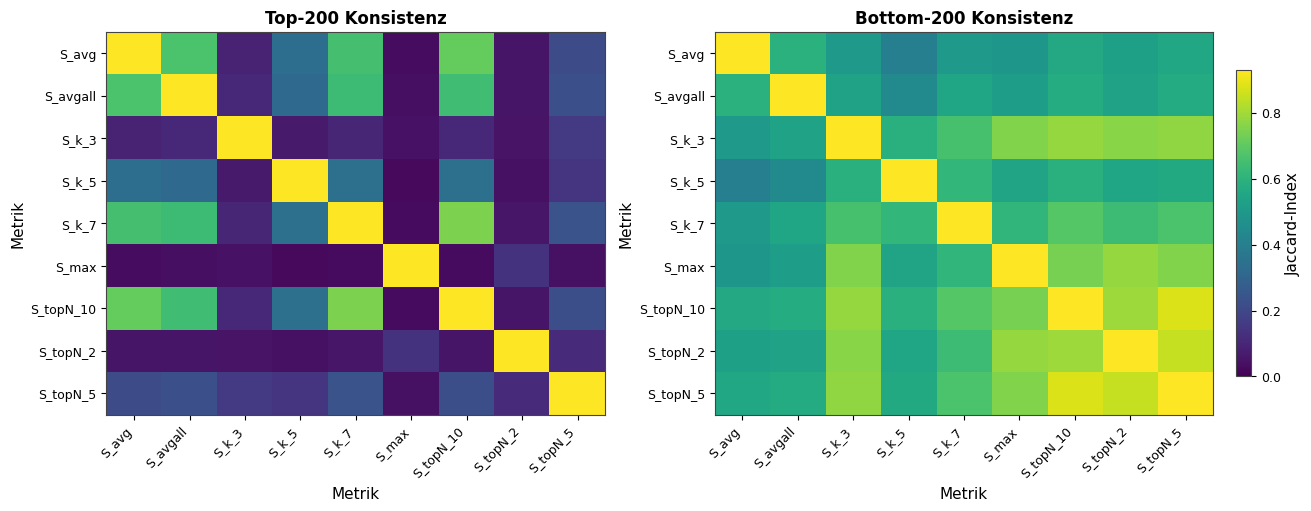

2. Creating Similarity Distribution Histograms...


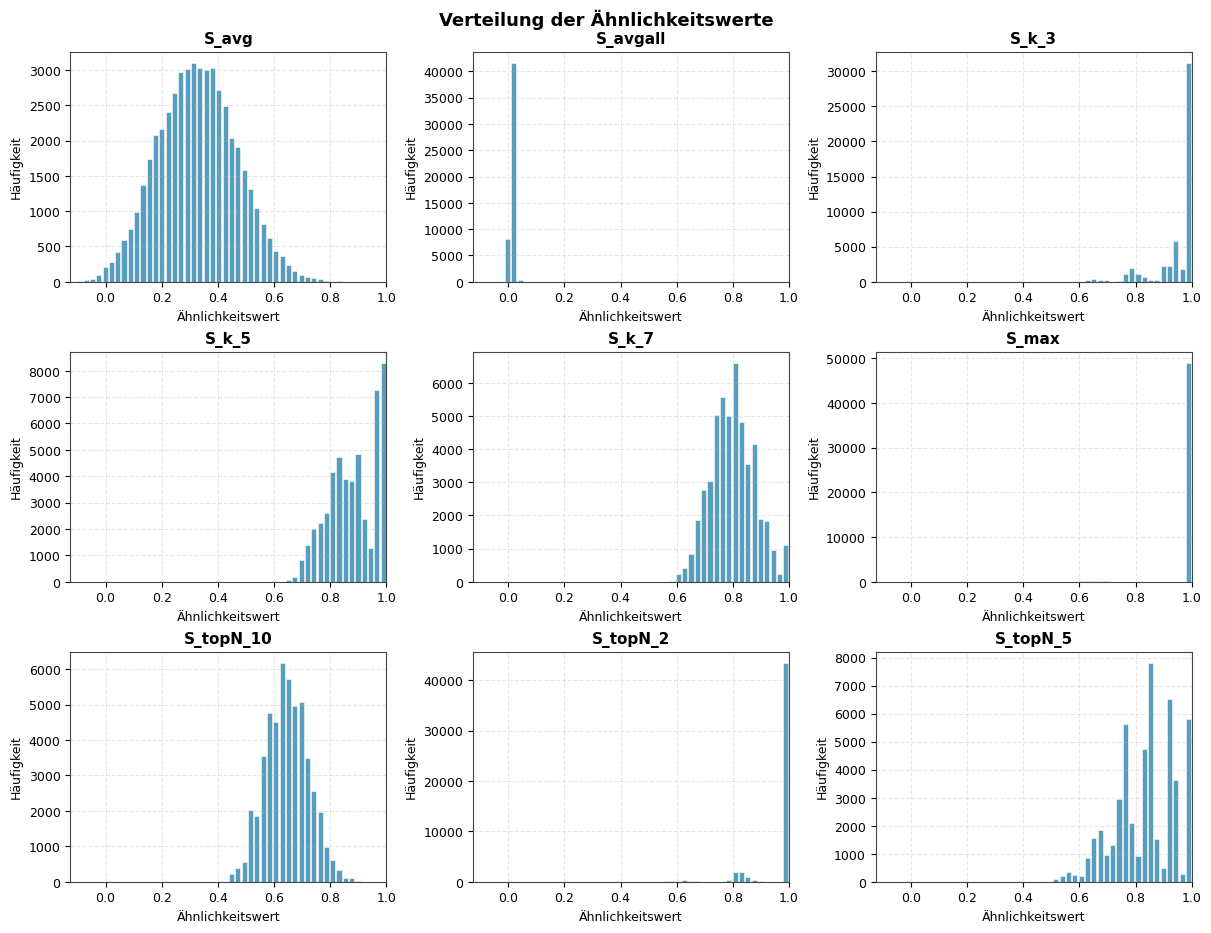

3. Creating Separation Score Analysis...


/tmp/ipykernel_686/3440010234.py:531: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(CMAP_SEQUENTIAL)


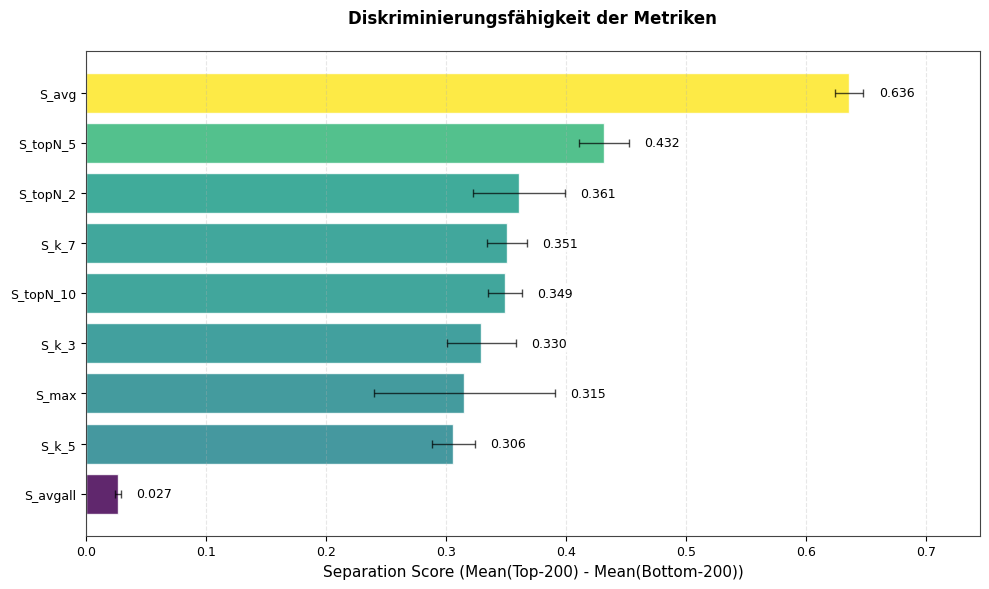

4. Creating Detailed Single Plots...

Report generation complete!
All figures saved to: figures
Generating Comprehensive Analysis Report
1. Creating Ranking Consistency Heatmaps...
INFO
[np.int64(2872), np.int64(4533)]
dict_keys(['top', 'bottom'])
INFO
[np.int64(2872), np.int64(4533)]
dict_keys(['top', 'bottom'])


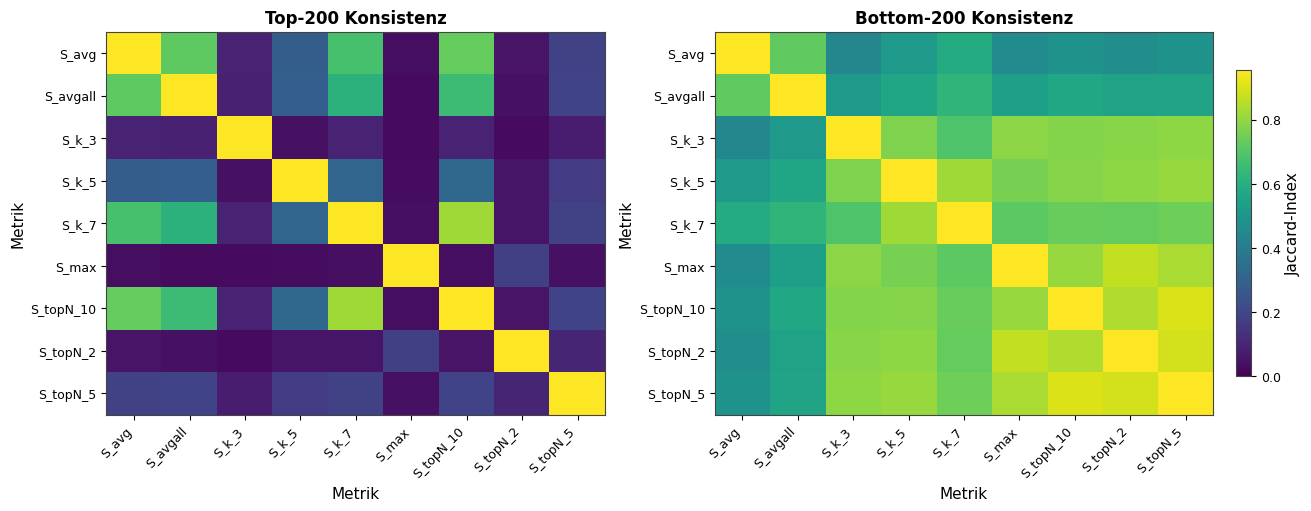

2. Creating Similarity Distribution Histograms...


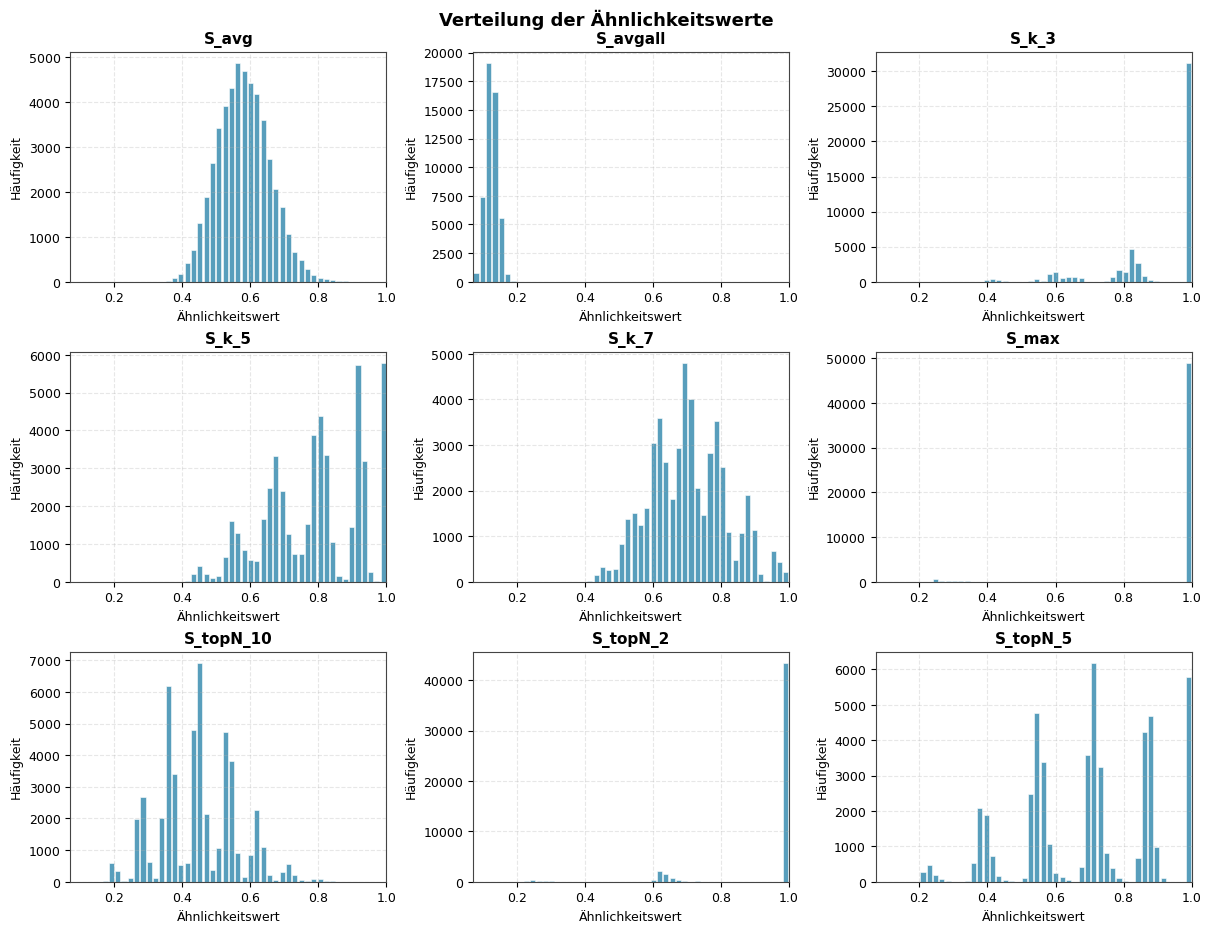

3. Creating Separation Score Analysis...


/tmp/ipykernel_686/3440010234.py:531: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(CMAP_SEQUENTIAL)


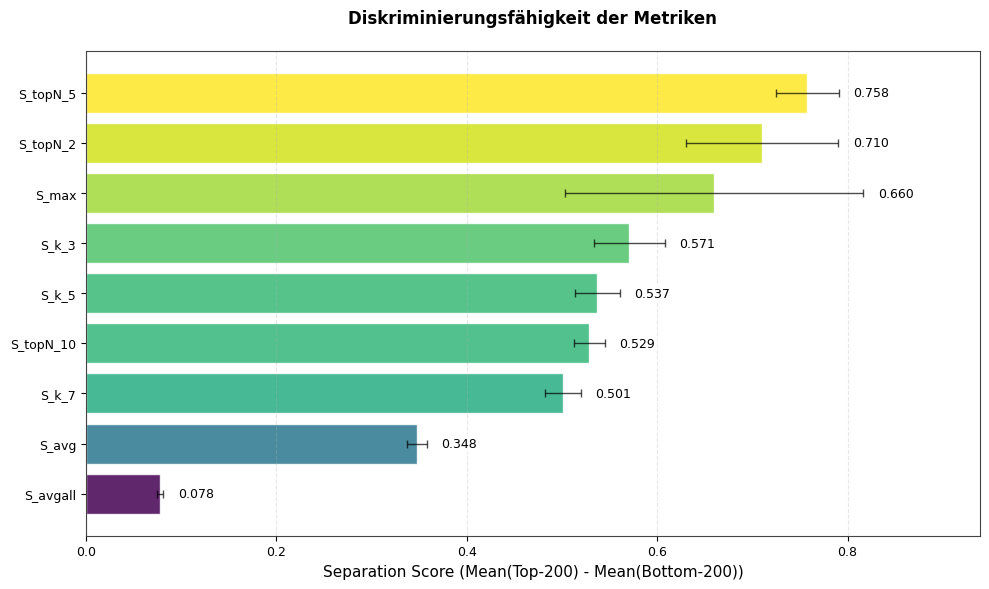

4. Creating Detailed Single Plots...

Report generation complete!
All figures saved to: figures


In [30]:
generate_comprehensive_report(results, model_idx=0, k=200)
generate_comprehensive_report(results, model_idx=1, k=200)